### Setting

In [15]:
import numpy as np
import pandas as pd
import pickle
import cpnet
from pathlib import Path
from scipy.sparse import load_npz
from tqdm.auto import tqdm
import itertools

In [2]:
# Raw data directory
DATA_DIR = Path('/Volumes/My Passport_2/Science-Society/data/processed')
NEWS_PATH  = DATA_DIR / "news_subject_by_year.pkl"
PAPER_PATH = DATA_DIR / "paper_subject_by_year.pkl"

# Working directory
BASE_DIR = Path('/Users/gre_en/Documents/Analysis/Projects/1_research/Sci-Soc')

# Processed data directory
NETWORKS_DIR = BASE_DIR / "data" / "processed" / "networks" # Network adj matrix
EMB_DIR = BASE_DIR / "data" / "processed" / "embeddings"    # Embedding vector directory

# Result directory 
CP_DIR = BASE_DIR  / "results" / "cp_results"
PLOT_DIR = BASE_DIR  / "results" / "figures"



# Make all directory
NETWORKS_DIR.mkdir(parents=True, exist_ok=True)
EMB_DIR.mkdir(parents=True, exist_ok=True)
CP_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

### Data import

In [5]:
def load_node_info(source, net_dir):
    with open(Path(net_dir) / f"{source}_node_info.pkl", "rb") as f:
        return pickle.load(f)

info = {"news": load_node_info("news", NETWORKS_DIR),
        "paper": load_node_info("paper", NETWORKS_DIR)}

# sanity check
print(len(list(NETWORKS_DIR.glob("*_fixed_adj_*.npz"))), "matrices")
print(info["news"].keys())
print("news  years", len(info["news"]["years"]), "V_t", info["news"]["V_t"][0], "->", info["news"]["V_t"][-1])
print("paper years", len(info["paper"]["years"]), "V_t", info["paper"]["V_t"][0], "->", info["paper"]["V_t"][-1])

68 matrices
dict_keys(['vocab', 'years', 'concept_freq_year', 'concept_freq_total', 'concept_share', 'concept_share_all', 'n_docs_all', 'n_docs_ge2', 'V_t', 'E_t'])
news  years 34 V_t 2434 -> 7883
paper years 34 V_t 12593 -> 18159


### Core-periphery

In [12]:
def node_mask(info, min_share, max_share):
    """Concept filter on the full-period share."""
    s = info["concept_share"]
    return (s >= min_share) & (s <= max_share)

def cp_network(W, keep):
    """
    Apply the concept mask and drop isolates.
    Returns the submatrix and the global index of each of its rows.
    """
    idx = np.where(keep)[0]
    sub = W[idx][:, idx].tocsr()
    act = np.where(sub.getnnz(axis=1) > 0)[0]
    return sub[act][:, act].tocsr(), idx[act]

def detect_once(Wc, gidx, method="km_er"):
    """
    One independent label-switching run. default is num_runs=10
    """
    algo = (cpnet.KM_ER(num_runs=1) if method == "km_er"
            else cpnet.KM_config(num_runs=1))
    algo.detect(Wc)

    c = np.asarray(algo.c_)                      # pair id per node
    x = np.asarray(algo.x_).astype(bool)         # core flag per node

    core_local = np.where(x)[0]
    sizes = np.bincount(c[core_local])
    sizes = sizes[sizes > 0]                     # groups holding core nodes

    return {
        "core": gidx[core_local],                # global indices
        "S": int(len(sizes)),
        "H": float(((sizes / sizes.sum()) ** 2).sum()) if sizes.size else np.nan,
        "Q_cp": float(algo.Q_),
    }

def run_cell(W, keep, n_runs, method="km_er", min_nodes=10):
    """One (year, spec) cell: mask once, then run detection n_runs=10 times."""
    Wc, gidx = cp_network(W, keep)
    if Wc.shape[0] < min_nodes:
        return None
    return {
        "V_t": int(Wc.shape[0]),
        "E_t": int(Wc.nnz // 2),
        "runs": [detect_once(Wc, gidx, method) for _ in range(n_runs)],
    }

def run_grid(source, info, grid, net_dir, out_dir,
             n_runs=1, method="km_er", tag="grid"):
    """
    Year-outer, spec-inner so each yearly matrix is read once.
    Saves per cell so an interrupted sweep resumes where it stopped.
    """
    out_dir = Path(out_dir) / tag
    out_dir.mkdir(parents=True, exist_ok=True)
    masks = {spec: node_mask(info, *spec) for spec in grid}

    todo = [(y, s) for y in info["years"] for s in grid
            if not (out_dir / f"{source}_{y}_{s[0]}_{s[1]}.pkl").exists()]
    bar = tqdm(total=len(todo), desc=f"{source}/{tag}")

    for year in info["years"]:
        pending = {s: m for s, m in masks.items()
                   if not (out_dir / f"{source}_{year}_{s[0]}_{s[1]}.pkl").exists()}
        if not pending:
            continue
        W = load_npz(Path(net_dir) / f"{source}_fixed_adj_{year}.npz")
        for spec, keep in pending.items():
            cell = run_cell(W, keep, n_runs, method)
            with open(out_dir / f"{source}_{year}_{spec[0]}_{spec[1]}.pkl", "wb") as f:
                pickle.dump(cell, f)
            bar.set_postfix(year=int(year), spec=f"{spec[0]}-{spec[1]}",
                            V=cell["V_t"] if cell else 0)
            bar.update(1)
    bar.close()
                
def select_spec(df, agg="median"):
    """Pick the grid cell with the highest representative Q_cp, per arena."""
    g = df.groupby(["min_share", "max_share"])["Q_cp"]
    s = g.median() if agg == "median" else g.mean()
    return s.idxmax(), s.sort_values(ascending=False)

In [7]:
def compute_indicators(source, info, grid, out_dir, n_runs=1, tag="grid"):
    
    out_dir = Path(out_dir) / tag
    rows = []

    for spec in grid:
        cells = {}
        for year in info["years"]:
            p = out_dir / f"{source}_{year}_{spec[0]}_{spec[1]}.pkl"
            with open(p, "rb") as f:
                cells[year] = pickle.load(f)

        for r in range(n_runs):
            prev = None
            for year in info["years"]:
                cell = cells[year]
                if cell is None:
                    prev = None
                    continue
                run = cell["runs"][r]
                cur = set(run["core"].tolist())

                row = {"min_share": spec[0], "max_share": spec[1],
                       "year": int(year), "run": r,
                       "V_t": cell["V_t"], "E_t": cell["E_t"],
                       "n_core": len(cur),
                       "R_t": len(cur) / cell["V_t"],
                       "S_t": run["S"], "H_t": run["H"], "Q_cp": run["Q_cp"]}
                if prev is not None and cur:
                    row["C_t"] = 1 - len(cur & prev) / len(cur)
                rows.append(row)
                prev = cur

    return pd.DataFrame(rows)

In [10]:
GRID = list(itertools.product(
    [0.0, 0.00001, 0.00025, 0.0005, 0.001],    # min share (Kedrick et al.)
    [0.005, 0.01, 0.05, 0.1, 1.0],             # max share
))

for spec in GRID:
    keep = node_mask(info["paper"], *spec)
    W = load_npz(NETWORKS_DIR / "paper_fixed_adj_2023.npz")
    Wc, _ = cp_network(W, keep)
    print(spec, "nodes", Wc.shape[0], "edges", Wc.nnz // 2)

(0.0, 0.005) nodes 17860 edges 1324069
(0.0, 0.01) nodes 18010 edges 1620736
(0.0, 0.05) nodes 18114 edges 1941816
(0.0, 0.1) nodes 18143 edges 1984278
(0.0, 1.0) nodes 18159 edges 2009733
(1e-05, 0.005) nodes 11929 edges 1264446
(1e-05, 0.01) nodes 12039 edges 1552378
(1e-05, 0.05) nodes 12110 edges 1858611
(1e-05, 0.1) nodes 12116 edges 1896692
(1e-05, 1.0) nodes 12119 edges 1919502
(0.00025, 0.005) nodes 2390 edges 553354
(0.00025, 0.01) nodes 2499 edges 713885
(0.00025, 0.05) nodes 2569 edges 855123
(0.00025, 0.1) nodes 2574 edges 867472
(0.00025, 1.0) nodes 2577 edges 874796
(0.0005, 0.005) nodes 1358 edges 310485
(0.0005, 0.01) nodes 1467 edges 420901
(0.0005, 0.05) nodes 1537 edges 513330
(0.0005, 0.1) nodes 1542 edges 520896
(0.0005, 1.0) nodes 1545 edges 525400
(0.001, 0.005) nodes 718 edges 133696
(0.001, 0.01) nodes 827 edges 202311
(0.001, 0.05) nodes 897 edges 258756
(0.001, 0.1) nodes 902 edges 263225
(0.001, 1.0) nodes 905 edges 265910


In [16]:
grid_df = {}
for source in ["news", "paper"]:
    run_grid(source, info[source], GRID, NETWORKS_DIR, CP_DIR, n_runs=1, tag="grid")
    d = compute_indicators(source, info[source], GRID, CP_DIR, n_runs=1, tag="grid")
    d["density"] = 2 * d.E_t / (d.V_t * (d.V_t - 1)).replace(0, np.nan)
    d.to_csv(CP_DIR / f"{source}_grid.csv", index=False)
    grid_df[source] = d

news/grid:   0%|          | 0/581 [00:00<?, ?it/s]

paper/grid:   0%|          | 0/850 [00:00<?, ?it/s]

In [17]:
for source, d in grid_df.items():
    print(f"\n=== {source} ===")
    _, ranking = select_spec(d)
    print("Q_cp ranking:"); print(ranking.round(4))
    print("\nnodes:"); print(d.pivot_table(index=["min_share","max_share"],
                                           columns="year", values="V_t").iloc[:, ::8])
    print("\ndensity:"); print(d.pivot_table(index=["min_share","max_share"],
                                             columns="year", values="density").iloc[:, ::8].round(3))


=== news ===
Q_cp ranking:
min_share  max_share
0.00000    1.000        0.4002
0.00001    1.000        0.3981
0.00000    0.100        0.3894
0.00001    0.100        0.3874
0.00000    0.050        0.3836
0.00001    0.050        0.3811
0.00025    1.000        0.3639
0.00050    1.000        0.3481
0.00025    0.100        0.3451
0.00000    0.010        0.3451
0.00001    0.010        0.3389
0.00025    0.050        0.3373
0.00100    1.000        0.3334
0.00050    0.100        0.3277
0.00000    0.005        0.3235
0.00001    0.005        0.3200
0.00050    0.050        0.3186
0.00100    0.100        0.3041
           0.050        0.2931
0.00025    0.010        0.2881
           0.005        0.2608
0.00050    0.010        0.2606
           0.005        0.2283
0.00100    0.010        0.2264
           0.005        0.2112
Name: Q_cp, dtype: float64

nodes:
year                   1990    1998    2006    2014    2022
min_share max_share                                        
0.00000   0.005      

In [20]:
BEST = {"news":  (0.0, 1.0),     
        "paper": (0.0, 1.0)}

main_df, band_df = {}, {}
for source, spec in BEST.items():
    run_grid(source, info[source], [spec], NETWORKS_DIR, CP_DIR, n_runs=10, tag="main")
    d = compute_indicators(source, info[source], [spec], CP_DIR, n_runs=10, tag="main")
    d.to_csv(CP_DIR / f"{source}_main.csv", index=False)
    b = d.groupby("year")[["C_t","R_t","S_t","H_t"]].agg(["mean","std","count"])
    b.to_csv(CP_DIR / f"{source}_band.csv")
    main_df[source], band_df[source] = d, b
    print(source, spec); print(b.xs("mean", axis=1, level=1).round(3).to_string())

news/main:   0%|          | 0/34 [00:00<?, ?it/s]

news (0.0, 1.0)
        C_t    R_t    S_t    H_t
year                            
1990    NaN  0.356  226.3  0.070
1991  0.693  0.435  159.4  0.053
1992  0.757  0.365  241.8  0.059
1993  0.663  0.369  224.2  0.066
1994  0.660  0.359  229.6  0.073
1995  0.650  0.342  243.5  0.079
1996  0.670  0.346  219.4  0.084
1997  0.714  0.365  268.8  0.086
1998  0.755  0.344  505.4  0.067
1999  0.621  0.336  552.5  0.064
2000  0.611  0.349  577.1  0.059
2001  0.593  0.344  546.1  0.062
2002  0.615  0.368  582.2  0.070
2003  0.592  0.342  540.6  0.071
2004  0.610  0.346  598.7  0.071
2005  0.600  0.353  627.5  0.069
2006  0.591  0.355  660.6  0.078
2007  0.625  0.343  677.5  0.091
2008  0.591  0.351  651.3  0.092
2009  0.563  0.345  641.3  0.096
2010  0.584  0.345  616.9  0.088
2011  0.577  0.339  641.9  0.089
2012  0.596  0.338  618.0  0.089
2013  0.588  0.325  613.3  0.094
2014  0.597  0.333  656.3  0.091
2015  0.590  0.338  656.2  0.089
2016  0.603  0.320  702.8  0.086
2017  0.645  0.317  817.1  

paper/main:   0%|          | 0/34 [00:00<?, ?it/s]

IOStream.flush timed out


paper (0.0, 1.0)
        C_t    R_t     S_t    H_t
year                             
1990    NaN  0.281  1155.5  0.089
1991  0.584  0.286  1180.5  0.083
1992  0.575  0.286  1210.3  0.083
1993  0.568  0.292  1291.6  0.081
1994  0.561  0.289  1255.6  0.084
1995  0.566  0.283  1256.5  0.085
1996  0.570  0.288  1248.7  0.083
1997  0.563  0.291  1328.6  0.081
1998  0.555  0.290  1284.1  0.082
1999  0.565  0.297  1415.4  0.076
2000  0.551  0.288  1413.3  0.080
2001  0.546  0.294  1461.5  0.076
2002  0.581  0.330  1580.4  0.054
2003  0.512  0.317  1576.8  0.062
2004  0.519  0.312  1564.1  0.065
2005  0.515  0.316  1562.4  0.063
2006  0.510  0.316  1644.6  0.060
2007  0.504  0.316  1614.2  0.060
2008  0.499  0.318  1628.1  0.059
2009  0.500  0.321  1617.9  0.058
2010  0.484  0.321  1614.3  0.058
2011  0.485  0.316  1634.0  0.059
2012  0.492  0.322  1663.8  0.058
2013  0.485  0.323  1658.5  0.058
2014  0.476  0.316  1637.1  0.060
2015  0.487  0.325  1659.8  0.059
2016  0.480  0.323  1672.5  0.0

### Visualize

In [37]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

YEAR_START, YEAR_END = 1990, 2023
YEAR_TICKS = [1990, 1995, 2000, 2005, 2010, 2015, 2020]
OUT_DIR = Path("figures")
PERIOD_BANDS = []          # e.g. [(1998, 2006), (2006, 2017)]
EVENTS = {}                # e.g. {2012: "AlexNet", 2016: "AlphaGo"}

PANELS = [  # key, color, ylabel, math label, percent axis
    ("cit",        "#FF1F5B", "Churn of Core Nodes",      "C_{it}", False),
    ("rit",        "#00CD6C", "Relat. No. of Core Nodes", "R_{it}", True),
    ("sit",        "#009ADE", "No. of Cores",             "S_{it}", False),
    ("herfindahl", "#AF58BA", "Concentration",            "H_{it}", False),
]
METRIC_MAP = {"C_t": "cit", "R_t": "rit", "S_t": "sit", "H_t": "herfindahl"}


def to_plot_frame(df_main, z=1.96):
    """
    Collapse the (year, run) table into the mean/ci columns the plots expect.

    The band is the spread across independent detection runs. Kedrick et al.
    take theirs from cross-subfield variation, which has no counterpart here:
    with two arenas there is no field axis, so the shading reports the
    stability of the detection algorithm rather than sampling uncertainty.
    """
    g = df_main.groupby("year")[list(METRIC_MAP)].agg(["mean", "std", "count"])
    out = pd.DataFrame({"year": g.index})
    for src, dst in METRIC_MAP.items():
        out[f"{dst}_mean"] = g[(src, "mean")].values
        out[f"{dst}_ci"] = (z * g[(src, "std")] / np.sqrt(g[(src, "count")])).values
    return out.reset_index(drop=True)


def add_period_bands(ax, bands=None, color="#000000", alpha=0.05):
    for lo, hi in (bands if bands is not None else PERIOD_BANDS):
        ax.axvspan(lo, hi, color=color, alpha=alpha, lw=0, zorder=0)


def add_events(ax, events=None, fontsize=8, color="gray"):
    ev = events if events is not None else EVENTS
    top = ax.get_ylim()[1]
    for yr, label in ev.items():
        if not (YEAR_START <= yr <= YEAR_END):
            continue
        ax.axvline(yr, color=color, lw=0.8, ls="--", alpha=0.6, zorder=1)
        ax.text(yr, top, f" {label}", rotation=90, va="top", ha="left",
                fontsize=fontsize, color=color, alpha=0.9)


def plot_metric(ax, df, measure, ci_col, color, ylabel, ylim,
                title_label, pct=False):
    add_period_bands(ax)

    plot_df = df.dropna(subset=[measure])
    sns.lineplot(data=plot_df, x="year", y=measure, color=color,
                 errorbar=None, ax=ax)
    ax.fill_between(plot_df["year"],
                    plot_df[measure] - plot_df[ci_col].fillna(0),
                    plot_df[measure] + plot_df[ci_col].fillna(0),
                    color=color, alpha=0.2)

    ax.set_xlim(YEAR_START, YEAR_END)
    ax.set_xticks(YEAR_TICKS)
    ax.set_ylim(*ylim)
    ax.set_aspect(1 / ax.get_data_ratio())
    ax.set_xlabel("Year", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(labelsize=10)

    add_events(ax)

    if pct:
        ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1.0))
    ax.set_title(rf"${{({title_label})}}$", loc="left")


def plot_cp_indices(paper_df, news_df, ylims=None, save=None):
    """
    Figure 3.3 — structural indices over time in both arenas.

    Limits default to the data range so the panels fit whatever the current
    spec produces; pass ylims once the values have settled.
    """
    fig, axs = plt.subplots(2, 4, figsize=(14, 7))
    for row, (df, dom) in enumerate([(paper_df, "paper"), (news_df, "news")]):
        for col, (key, color, ylabel, _, pct) in enumerate(PANELS):
            m, ci = f"{key}_mean", f"{key}_ci"
            if ylims:
                ylim = ylims[dom][key]
            else:
                lo = (df[m] - df[ci].fillna(0)).min()
                hi = (df[m] + df[ci].fillna(0)).max()
                pad = 0.08 * (hi - lo) if hi > lo else 0.1
                ylim = (lo - pad, hi + pad)
            plot_metric(axs[row, col], df, m, ci, color, ylabel, ylim,
                        "abcdefgh"[row * 4 + col], pct=pct)

    fig.text(0.005, 0.975, "Paper / scientific domain", fontsize=15,
             transform=fig.transFigure)
    fig.text(0.005, 0.49, "News / social domain", fontsize=15,
             transform=fig.transFigure)
    plt.tight_layout(rect=(0.005, 0, 1, 0.98), h_pad=3, w_pad=2)

    if save:
        plt.savefig(PLOT_DIR / save, bbox_inches="tight", dpi=300)
    plt.show()

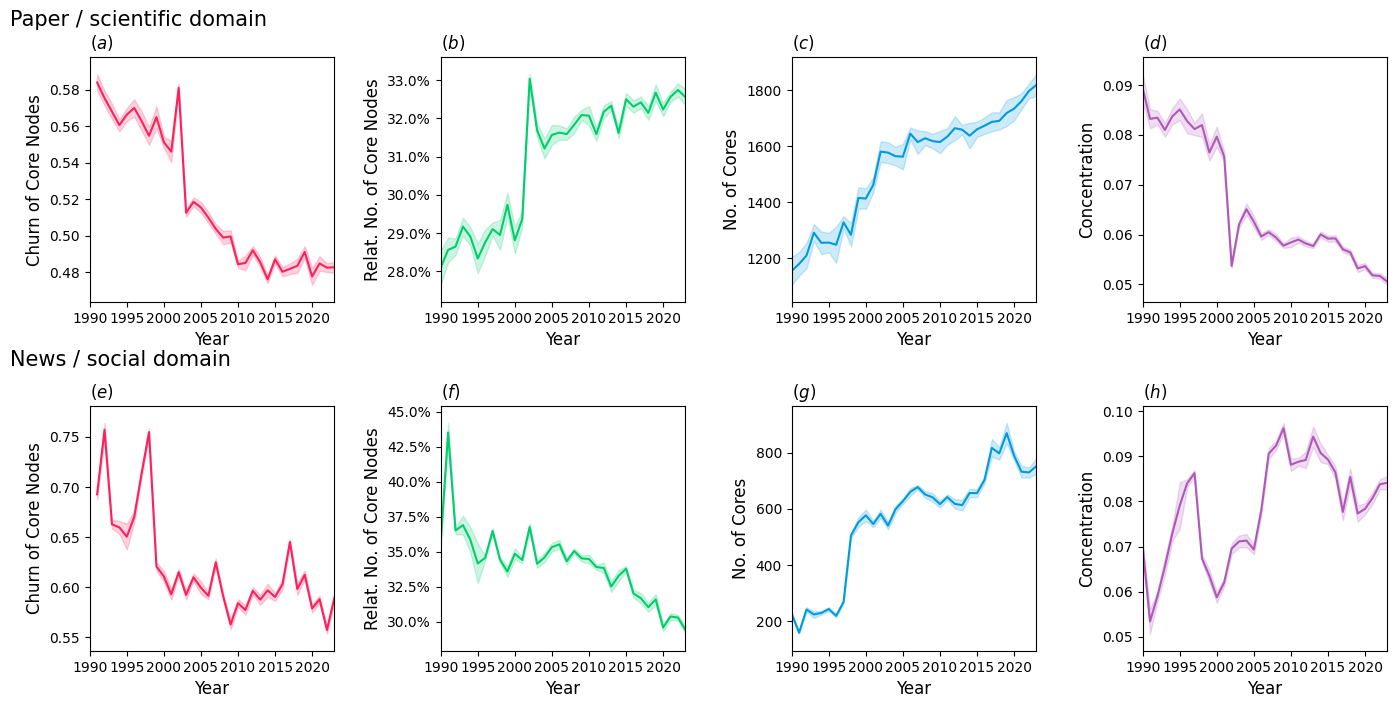

In [38]:
main_df = {s: pd.read_csv(CP_DIR / f"{s}_main.csv") for s in ["news", "paper"]}

plot_cp_indices(to_plot_frame(main_df["paper"]),
                to_plot_frame(main_df["news"]),
                save="fig_cp_indices.png")

In [ ]:
# YLIMS = {
#     "paper": {"cit": (0.4, 0.7), "rit": (0.35, 0.45),
#               "sit": (1000, 2300), "herfindahl": (0.0, 0.23)},
#     "news":  {"cit": (0.4, 0.7), "rit": (0.5, 0.7),
#               "sit": (0, 1300), "herfindahl": (0.0, 0.23)},
# }
# plot_cp_indices(to_plot_frame(main_df["paper"]), to_plot_frame(main_df["news"]), ylims=YLIMS, save="fig_cp_indices.png")